# Binarization with scBoolSeq

1) Set the GO per macrostate for the evaluation of the HVG and binarization results 
2) Binarize the matrix, the workflow is based on the raw matrix, and the macrostates are binarized separately
3) Evaluate the binarization result 

In [1]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_raw_macro.h5ad"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
macrostates_computed="timepoint" # stream2 or timepoint
binarization ="scBoolSeq" # type of binarization choosen : scBoolSeq or classic (based on the count)

In [20]:
import sys
#!pip install gseapy
#!pip install scboolseq
import scanpy as sc
import numpy as np
import pandas as pd
from scboolseq import scBoolSeq
import gc
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import gseapy as gp
from gseapy import get_library
from scipy.stats import fisher_exact
import json
import requests
from scipy.signal import argrelmin
from scipy.stats import gaussian_kde
#! pip install goatools
#!pip install leidenalg

In [3]:
warnings.filterwarnings("ignore")
adata = sc.read(input_file) # read data 
if adata.X.max() > 10 : # check if is raw data, need to be > 10
    # Normalization
    sc.pp.normalize_total(adata) # 
    sc.pp.log1p(adata)
    print("=== This dataset is now normalised")
else :
    print("=== This dataset appears to have already been normalised")

# Verify if we have only the cells expected and the macrostates 
print("=== Cell type and macrostates in our dataset")
print(adata.obs["Annotation"].unique())
print(adata.obs["macrostates"].unique())

=== This dataset is now normalised
=== Cell type and macrostates in our dataset
['B intermediate' 'B naive' 'B' 'B memory' 'Bridge']
['I2' 'None' 'I1' 'T1' 'T3' 'T2']


# 1) Binarization with scBoolSeq

Binarization macrostates separately : keep the genes DEG between all the macrostates

In [32]:
if binarization == "scBoolSeq":
    warnings.filterwarnings("ignore")

    # Delete cells with macrostates == "None"
    adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()

    macrostates = ['I1', 'I2', 'T1', 'T2', "T3"]

    binarized_states = {}
    adata_ct_dict = {}
    deg_lists_up = {}
    deg_lists_down = {}
    enrich_results = {}

    for ct in macrostates:
        print(f"\n{'='*50}")
        print(f"Processing {ct}...")

        adata_ct = adata[adata.obs['macrostates'] == ct].copy()
        n_cells = adata_ct.n_obs
        print(f"  {n_cells} cells")

        # STEP 1 : Differential Gene Expression to keep the main genes variable between macrostates 
        sc.tl.rank_genes_groups(adata_no_none, groupby="macrostates", groups=[ct], reference="rest", method="wilcoxon",use_raw=False)
        df = sc.get.rank_genes_groups_df(adata_no_none, group=ct)
        # keep the significant genes and with high variation log(FC) > 0.5 ou <-0.5
        df_sig = df[(df["pvals_adj"] < 0.05)&((df["logfoldchanges"] > 0.5) |(df["logfoldchanges"] < -0.5))]  
        df_up = df[(df["pvals_adj"] < 0.05) & (df["logfoldchanges"] > 0.5)]
        df_down = df[(df["pvals_adj"] < 0.05) & (df["logfoldchanges"] < -0.5)]

        deg_lists_up[ct] = df_up["names"].tolist()
        deg_lists_down[ct] = df_down["names"].tolist()  
        n_genes = df_sig.shape[0]
        genes_to_keep = df_sig['names'].tolist()
        
        print(f" {n_genes} genes after DEG")

        # STEP 2 : DataFrame
        adata_ct_deg = adata_ct[:, genes_to_keep].copy()
        X_full = adata_ct_deg.X
        if not isinstance(X_full, np.ndarray):
            X_full = X_full.toarray()

        expr_df_full = pd.DataFrame(
            X_full,
            index=adata_ct_deg.obs_names,
            columns=adata_ct_deg.var_names)

        print(f"DataFrame created with {expr_df_full.shape[1]} genes DEG")

        # Remove all-zero genes
        expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
        print(f" {expr_df_full.shape[1]} genes after removing all-zero")

        # STEP 3 : scBoolSeq model
        scbool = scBoolSeq(
            zeroinf_binarizer="quantile",
            margin_quantile=0.2,
            dor_threshold=0.85,
            alpha=0
        )

        scbool.fit(expr_df_full)
        print("  scBoolSeq fitted")

        # STEP 4 : Binarization
        binarized = scbool.binarize(expr_df_full)

        # STEP 5 : Majority vote
        def majority_vote(col):
            if col.isna().mean() > 0.5:
                return np.nan
            valid = col.dropna()
            if (valid == 0).mean() > 0.6:
                return 0
            elif (valid == 1).mean() > 0.6:
                return 1
            return np.nan

        aggregated = binarized.apply(majority_vote, axis=0)
        binarized_states[ct] = aggregated

        n_ones  = (aggregated == 1).sum()
        n_zeros = (aggregated == 0).sum()
        n_nan   = aggregated.isna().sum()
        percent_ones=(n_ones*100)/(n_ones+n_zeros+n_nan)
        percent_zero=(n_zeros*100)/(n_ones+n_zeros+n_nan)
        percent_nan=(n_nan*100)/(n_ones+n_zeros+n_nan)

        print(f"  {ct}: {n_cells} cells → {n_ones} genes=1, {n_zeros} genes=0, {n_nan} genes=NaN")
        print(f"{percent_ones:.2f} % genes=1, {percent_zero:.2f} % genes=0, {percent_nan:.2f} % genes=NaN")

        del adata_ct, expr_df_full, scbool
        gc.collect()

    print("\nDone!")


Processing I1...
  5018 cells
 2359 genes after DEG
DataFrame created with 2359 genes DEG
 2356 genes after removing all-zero
  scBoolSeq fitted
  I1: 5018 cells → 17 genes=1, 116 genes=0, 2223 genes=NaN
0.72 % genes=1, 4.92 % genes=0, 94.35 % genes=NaN

Processing I2...
  1015 cells
 1266 genes after DEG
DataFrame created with 1266 genes DEG
 1262 genes after removing all-zero
  scBoolSeq fitted
  I2: 1015 cells → 18 genes=1, 80 genes=0, 1164 genes=NaN
1.43 % genes=1, 6.34 % genes=0, 92.23 % genes=NaN

Processing T1...
  264 cells
 3343 genes after DEG
DataFrame created with 3343 genes DEG
 3343 genes after removing all-zero
  scBoolSeq fitted
  T1: 264 cells → 71 genes=1, 309 genes=0, 2963 genes=NaN
2.12 % genes=1, 9.24 % genes=0, 88.63 % genes=NaN

Processing T2...
  1797 cells
 2859 genes after DEG
DataFrame created with 2859 genes DEG
 2859 genes after removing all-zero
  scBoolSeq fitted
  T2: 1797 cells → 29 genes=1, 236 genes=0, 2594 genes=NaN
1.01 % genes=1, 8.25 % genes=0, 9

Test : adataptive threshold for the majority vote based on the distribution 

In [28]:
warnings.filterwarnings("ignore")

def find_valley_thresholds(values, bandwidth=0.1, order=30):
    values = values[~np.isnan(values)]
    kde = gaussian_kde(values, bw_method=bandwidth)
    x = np.linspace(values.min(), values.max(), 1000)
    density = kde(x)
    minima_idx = argrelmin(density, order=order)[0]
    return x[minima_idx]

    
# Delete cells with macrostates == "None"
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()
macrostates = ['I1', 'I2', 'T1', 'T2', 'T3']
binarized_states = {}
adata_ct_dict = {}
deg_lists_up = {}
deg_lists_down = {}
enrich_results = {}
thresholds_per_ct = {}

def find_valley_thresholds(values, bandwidth=0.1, order=30):
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.array([])
    kde = gaussian_kde(values, bw_method=bandwidth)
    x = np.linspace(values.min(), values.max(), 1000)
    density = kde(x)
    minima_idx = argrelmin(density, order=order)[0]
    return x[minima_idx]

for ct in macrostates:
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")
    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"{n_cells} cells")

    # STEP 1 : DEG
    sc.tl.rank_genes_groups(adata_no_none, groupby="macrostates", groups=[ct], reference="rest", method="wilcoxon", use_raw=False)
    df = sc.get.rank_genes_groups_df(adata_no_none, group=ct)
    df_sig  = df[(df["pvals_adj"] < 0.05) & ((df["logfoldchanges"] > 0.5) | (df["logfoldchanges"] < -0.5))]
    df_up   = df[(df["pvals_adj"] < 0.05) & (df["logfoldchanges"] > 0.5)]
    df_down = df[(df["pvals_adj"] < 0.05) & (df["logfoldchanges"] < -0.5)]
    deg_lists_up[ct]   = df_up["names"].tolist()
    deg_lists_down[ct] = df_down["names"].tolist()
    genes_to_keep = df_sig["names"].tolist()
    n_genes = df_sig.shape[0]
    print(f"{n_genes} genes after DEG")

    # STEP 2 : DataFrame
    adata_ct_deg = adata_ct[:, genes_to_keep].copy()
    X_full = adata_ct_deg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()
    expr_df_full = pd.DataFrame(X_full, index=adata_ct_deg.obs_names, columns=adata_ct_deg.var_names)
    print(f"DataFrame created with {expr_df_full.shape[1]} genes DEG")
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f"{expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : scBoolSeq
    scbool = scBoolSeq(zeroinf_binarizer="quantile", margin_quantile=0.2, dor_threshold=0.85, alpha=0)
    scbool.fit(expr_df_full)
    binarized = scbool.binarize(expr_df_full)

    # STEP 4 : Proportions per genes
    gene_stats = {}
    for gene in binarized.columns:
        col = binarized[gene]
        gene_stats[gene] = {
            "prop_1":   (col == 1).mean(),
            "prop_0":   (col == 0).mean(),
            "prop_nan": col.isna().mean()
        }
    stats_df = pd.DataFrame(gene_stats).T

    # STEP 5 : Thresholds by KDE valley
    t_on  = find_valley_thresholds(stats_df["prop_1"].values)
    t_off = find_valley_thresholds(stats_df["prop_0"].values)
    t_nan = find_valley_thresholds(stats_df["prop_nan"].values)

    thresholds_per_ct[ct] = {
        "t_on":  t_on,
        "t_off": t_off,
        "t_nan": t_nan
    }

    print(f"Thresholds ON  : {np.round(t_on,  3)}")
    print(f"Thresholds OFF : {np.round(t_off, 3)}")
    print(f"Thresholds NaN : {np.round(t_nan, 3)}")

    def majority_vote_adaptive(col, t_on, t_off, t_nan):
        seuil_on  = t_on[-1]  if len(t_on)  > 0 else 0.5
        seuil_off = t_off[-1] if len(t_off) > 0 else 0.5
        seuil_nan = t_nan[-2] if len(t_nan) > 0 else 0.8

        prop_nan = col.isna().mean()
        prop_1   = (col == 1).mean()
        prop_0   = (col == 0).mean()

        if prop_nan > seuil_nan:
            return np.nan

        if prop_1 > seuil_on:
            return 1
        elif prop_0 > seuil_off:
            return 0
        else:
            return np.nan

    aggregated = binarized.apply(lambda col: majority_vote_adaptive(col, t_on, t_off, t_nan),axis=0)
    binarized_states[ct] = aggregated
    print(f"ON: {(aggregated == 1).sum()} | OFF: {(aggregated == 0).sum()} | NaN: {aggregated.isna().sum()}")
    n_ones  = (aggregated == 1).sum()
    n_zeros = (aggregated == 0).sum()
    n_nan   = aggregated.isna().sum()
    percent_ones=(n_ones*100)/(n_ones+n_zeros+n_nan)
    percent_zero=(n_zeros*100)/(n_ones+n_zeros+n_nan)
    percent_nan=(n_nan*100)/(n_ones+n_zeros+n_nan)

    print(f"  {ct}: {n_cells} cells → {n_ones} genes=1, {n_zeros} genes=0, {n_nan} genes=NaN")
    print(f"{percent_ones:.2f} % genes=1, {percent_zero:.2f} % genes=0, {percent_nan:.2f} % genes=NaN")

    del adata_ct, expr_df_full, scbool
    gc.collect()



Processing I1...
5018 cells
2359 genes after DEG
DataFrame created with 2359 genes DEG
2356 genes after removing all-zero
Thresholds ON  : [0.081 0.266 0.451]
Thresholds OFF : [0.107 0.281]
Thresholds NaN : [0.303 0.686 0.907]
ON: 196 | OFF: 210 | NaN: 1950
  I1: 5018 cells → 196 genes=1, 210 genes=0, 1950 genes=NaN
8.32 % genes=1, 8.91 % genes=0, 82.77 % genes=NaN

Processing I2...
1015 cells
1266 genes after DEG
DataFrame created with 1266 genes DEG
1262 genes after removing all-zero
Thresholds ON  : [0.081 0.26  0.41  0.482 0.561]
Thresholds OFF : [0.105 0.283 0.52 ]
Thresholds NaN : [0.301 0.692 0.912]
ON: 46 | OFF: 155 | NaN: 1061
  I2: 1015 cells → 46 genes=1, 155 genes=0, 1061 genes=NaN
3.65 % genes=1, 12.28 % genes=0, 84.07 % genes=NaN

Processing T1...
264 cells
3343 genes after DEG
DataFrame created with 3343 genes DEG
3343 genes after removing all-zero
Thresholds ON  : [0.082 0.253 0.747]
Thresholds OFF : [0.099 0.261]
Thresholds NaN : [0.37  0.67  0.906]
ON: 17 | OFF: 643 

In [13]:
pd.DataFrame.from_dict(binarized_states, orient="index").fillna('')

,KLHL17,ISG15,TNFRSF4,B3GALT6,MMP23B,PRKCZ,ARHGEF16,DFFB,RNF207,ESPN,...,DCX,WDR44,IL13RA1,LONRF3,PHF6,SMIM10,RTL8B,ZNF449,CD40LG,L1CAM
I1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,,,,,,,,,,
I2,,1.0,0.0,,,,,,,,...,,,,,,,,,,
T2,,0.0,0.0,,,,,,,,...,,,,,,,,,,
T3,,1.0,0.0,,,,,,,,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
T1,,,,,,,,,,,...,,,,,,,,,,


In [5]:
all_genes = adata.var_names
hvg_mask = np.array([gene in all_hvg for gene in all_genes])
print(f"Total genes: {len(all_genes)}")

Total genes: 18723
HVG macrostates: 0 genes


In [14]:
with open("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/data_binarized.json", "w") as f:
    json.dump(binarized_states, f)

# 2) Pathway enrichment per macrostates 

Enrichment for I1

Top 2 pathways for I1:
  - Plasma Membrane Bounded Cell Projection Assembly (GO:0120031) (adj p=1.51e-09)
  - Cilium Organization (GO:0044782) (adj p=8.06e-09)
Enrichment for I2

Top 2 pathways for I2:
  - Defense Response to Virus (GO:0051607) (adj p=3.71e-10)
  - Negative Regulation of Viral Process (GO:0048525) (adj p=7.46e-06)
Enrichment for T1

Top 2 pathways for T1:
  - Inflammatory Response (GO:0006954) (adj p=7.03e-10)
  - Cellular Response to Low-Density Lipoprotein Particle Stimulus (GO:0071404) (adj p=1.27e-06)
Enrichment for T2

Top 2 pathways for T2:
  - B Cell Receptor Signaling Pathway (GO:0050853) (adj p=1.90e-05)
  - B Cell Activation (GO:0042113) (adj p=1.22e-03)
Enrichment for T3

Top 2 pathways for T3:
  - Ribosome Biogenesis (GO:0042254) (adj p=2.47e-44)
  - Mitochondrial Translation (GO:0032543) (adj p=4.82e-39)


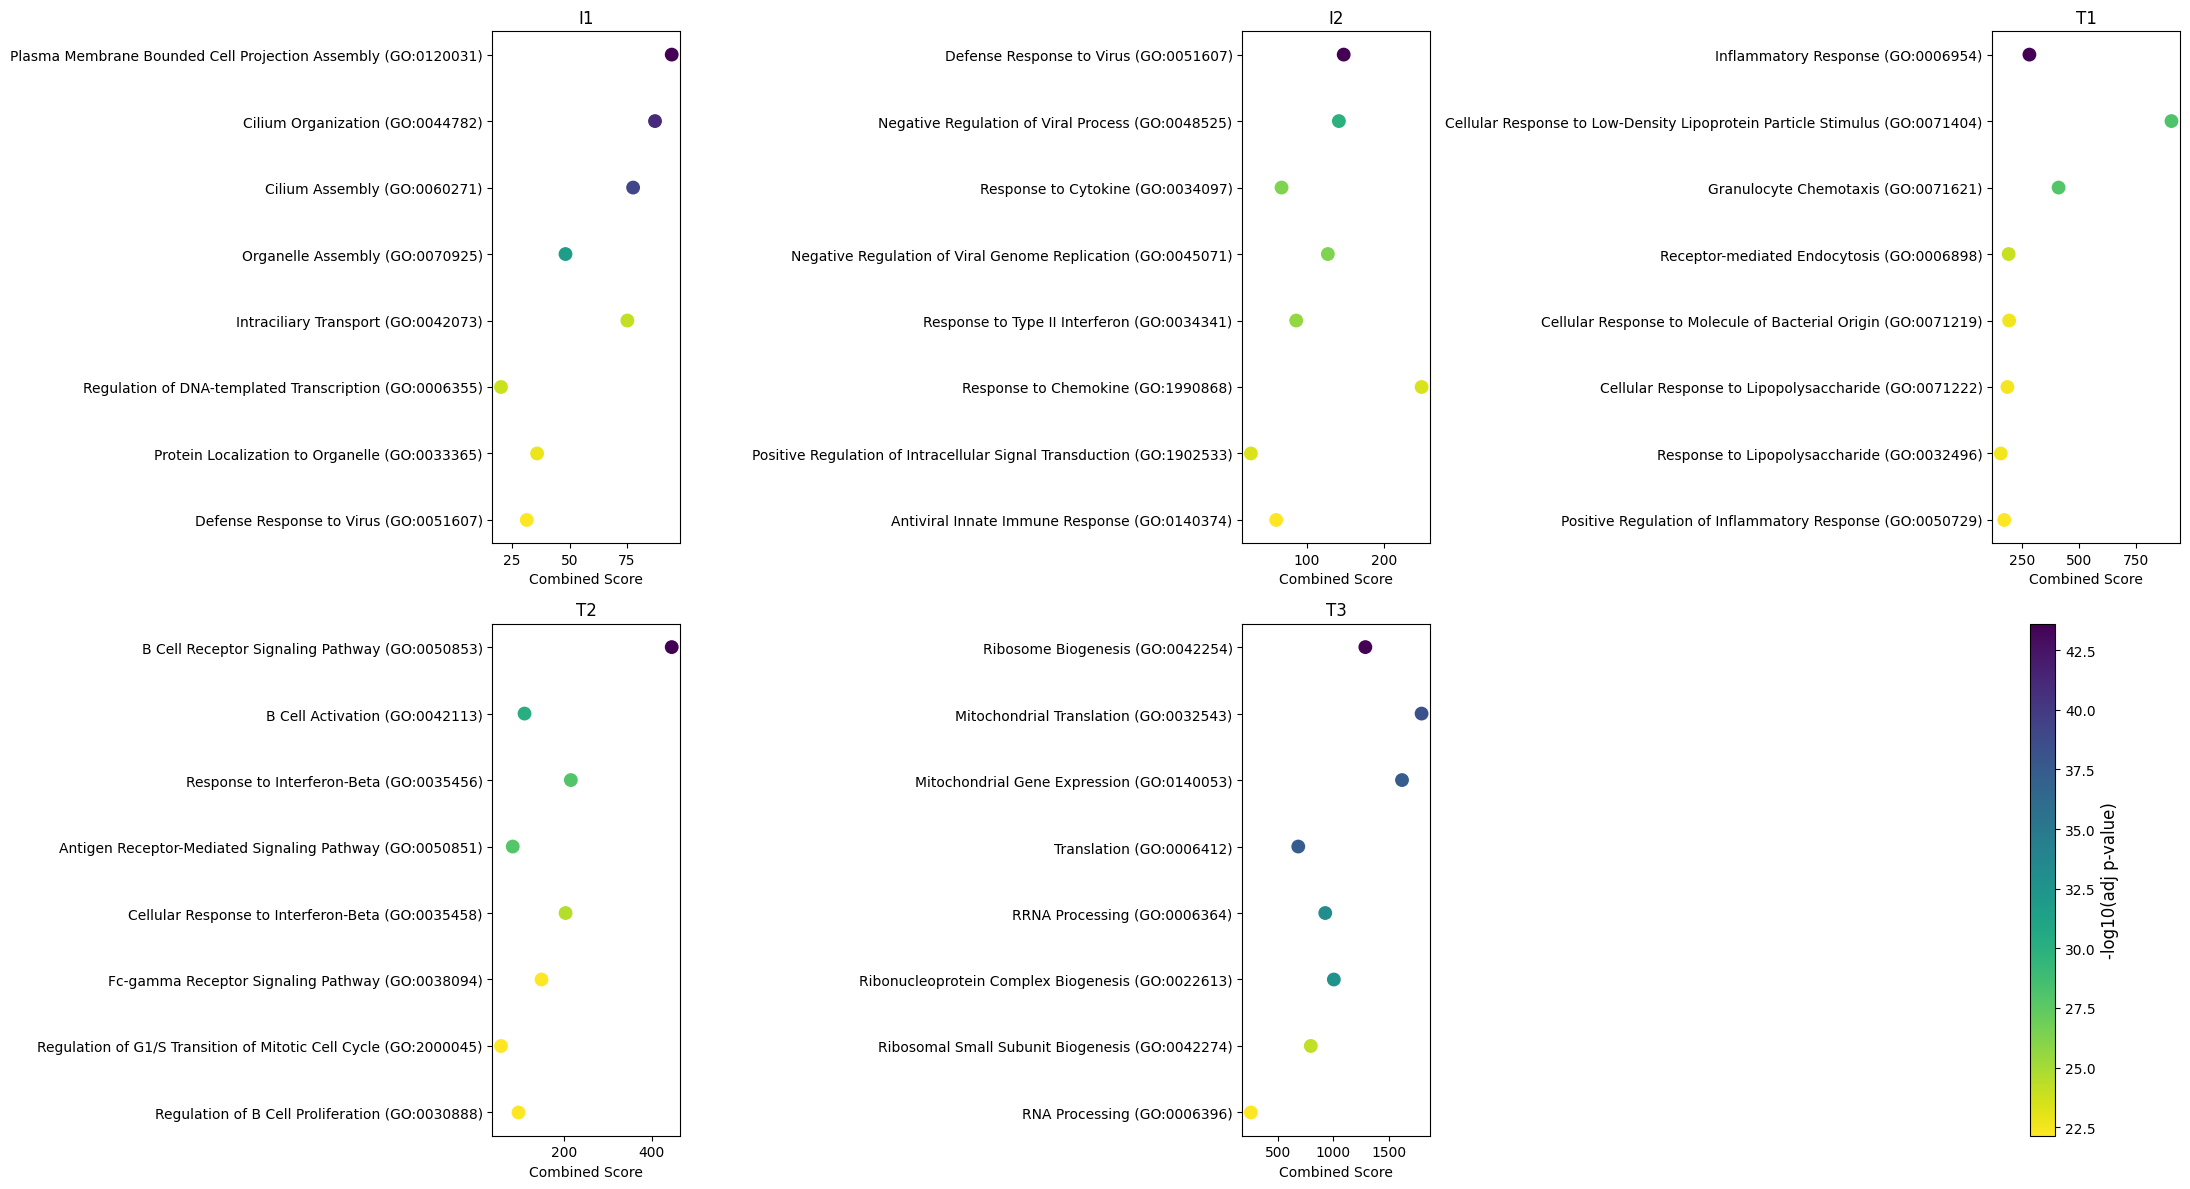

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

enrich_results = {}

for i, ct in enumerate(macrostates):
    print(f"Enrichment for {ct}")
    enr = gp.enrichr(
        gene_list=deg_lists_up[ct],
        gene_sets="GO_Biological_Process_2026",# Reactome_Pathways_2024 
        organism="human",
        outdir=None)

    df = enr.results.copy()

    # Top pathways
    df_sorted = df.sort_values("Adjusted P-value")

    top2 = df_sorted.head(2)
    print(f"\nTop 2 pathways for {ct}:")
    for _, row in top2.iterrows():
        print(f"  - {row['Term']} (adj p={row['Adjusted P-value']:.2e})")

    df = df.sort_values("Adjusted P-value").head(8)

    df["GeneRatio"] = df["Overlap"].str.split("/").apply(lambda x: int(x[0]) / int(x[1]))

    # Plot
    scp = axes[i].scatter(
        x=df["Combined Score"],
        y=df["Term"],
        c=-np.log10(df["Adjusted P-value"]),
        s=80, cmap="viridis_r")

    axes[i].set_title(ct)
    axes[i].set_xlabel("Combined Score")
    axes[i].set_ylabel("")
    axes[i].invert_yaxis()

cax = axes[-1]
cax.axis("off") 

cbar = fig.colorbar(scp,ax=cax,fraction=0.8)
cbar.set_label("-log10(adj p-value)", fontsize=12)
plt.subplots_adjust(wspace=0.5, hspace=0.4)
plt.tight_layout()
fig.savefig(f"{output_directory}/GO_barplot.png",dpi=300,bbox_inches="tight")
plt.show()

Save the binarized data for BoNesis 

# 3) Evaluate the binarization

Pathway enrichment (Scanpy or AUCell)

In [106]:
immune_pathways = {
    k: v for k, v in reactome.items()
    if "costimulation " in k.lower()
}
list(immune_pathways.keys())[:50]

['Costimulation by the CD28 Family']

Pathways score on on all genes selected by DEG per macrostates 

In [7]:
def get_pathways_dict():
    url = "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=GO_Biological_Process_2026"
    r = requests.get(url)

    pathways = {}
    for line in r.text.strip().split("\n"):
        parts = line.split("\t")
        if len(parts) > 2:
            pathways[parts[0]] = parts[2:]
    return pathways

pathway = get_pathways_dict()

pathways = {
    "Plasma Membrane": pathway["Plasma Membrane Bounded Cell Projection Assembly (GO:0120031)"], # I1
    "Cilium Organization": pathway["Cilium Organization (GO:0044782)"],
    "Defense Response": pathway["Defense Response to Virus (GO:0051607)"], # I2
    "Viral Regulation": pathway["Negative Regulation of Viral Process (GO:0048525)"], 
    "Inflammatory Response": pathway["Inflammatory Response (GO:0006954)"], # T1
    "Cellular Response": pathway["Cellular Response to Low-Density Lipoprotein Particle Stimulus (GO:0071404)"], 
    "B Cell Receptor": pathway["B Cell Receptor Signaling Pathway (GO:0050853)"],# T2
    "B Cell Activation": pathway["B Cell Activation (GO:0042113)"],
    "Ribosome Biogenesis": pathway["Ribosome Biogenesis (GO:0042254)"],# T3
    "Mitochondrial Translation": pathway["Mitochondrial Translation (GO:0032543)"]
}

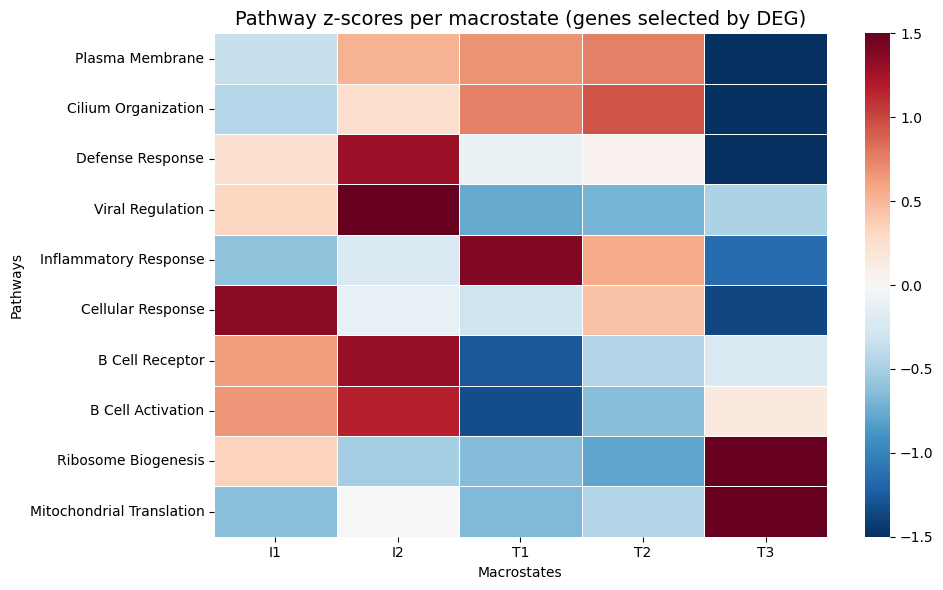

In [26]:
# Compute score for each cell for each pathway
for name, gene_list in pathways.items():
    gene_list_filtered = [g for g in gene_list if g in adata_no_none.var_names]
    if len(gene_list_filtered) == 0:
        print(f"No genes found for {name}")
        continue
    sc.tl.score_genes(adata_no_none, gene_list=gene_list_filtered, score_name=name)

scores = list(pathways.keys())
mean_scores = (
    adata_no_none.obs
    .groupby("macrostates")[scores]
    .mean())
mean_scores_z_all = mean_scores.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

# Plot
plt.figure(figsize=(10, 6))

sns.heatmap(
    mean_scores_z_all.T,
    cmap="RdBu_r", center=0,
    linewidths=0.5,
    cbar=True,vmin=-1.5,
    vmax=1.5,
    yticklabels=True
)
plt.title("Pathway z-scores per macrostate (genes selected by DEG)", fontsize=14)
plt.xlabel("Macrostates")
plt.ylabel("Pathways")
plt.tight_layout()
plt.savefig(f"{output_directory}/pathways_combined_heatmap.png", dpi=300)
plt.show()

Look at pathways selected in the binarised matrix

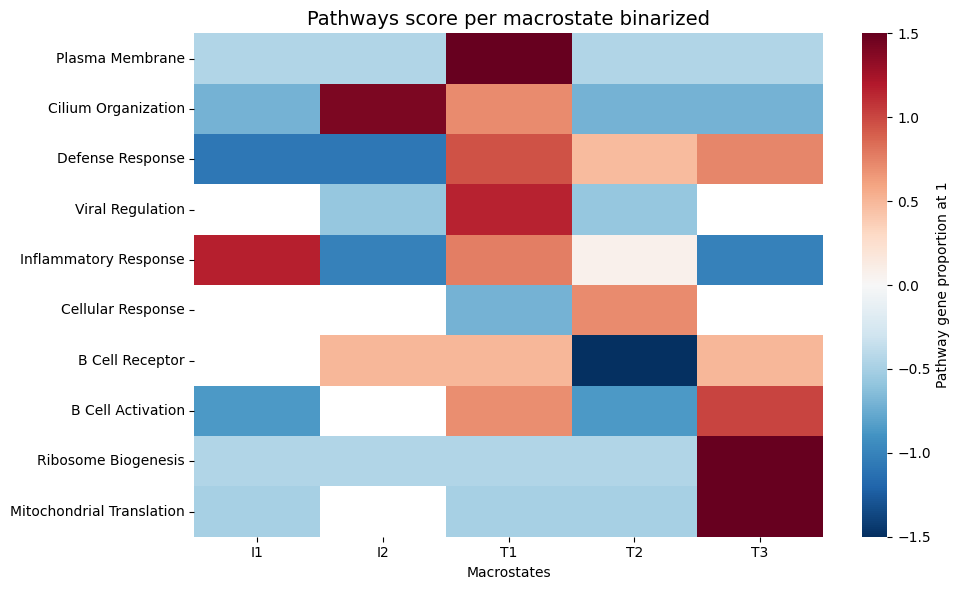

In [33]:
binary_matrix = pd.DataFrame.from_dict(binarized_states, orient="index").fillna(np.nan)

binary_matrix = binary_matrix.apply(pd.to_numeric, errors="coerce")

scores = {}

for name, genes in pathways.items():
    # keep genes only present in binary_matrix
    genes_present = [g for g in genes if g in binary_matrix.columns]
    if len(genes_present) == 0:
        # pathway empthy
        scores[name] = pd.Series(np.nan, index=binary_matrix.index, dtype=float)
        continue

    mat = binary_matrix.loc[:, genes_present]

    num = (mat == 1).sum(axis=1)          # number of genes activated (=1) per macrostates
    den = mat.notna().sum(axis=1)         # number of 0 or 1, not NA
    score = num / den                     # if den > 0, else NaN

    scores[name] = score

scores_df = pd.DataFrame(scores)
order = ["I1", "I2", "T1", "T2", "T3"]
scores_df = scores_df.loc[order]
scores_df_z = scores_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
scores_df_z = scores_df_z.T

#Plot 
plt.figure(figsize=(10, 6))
sns.heatmap(scores_df_z,cmap="RdBu_r",annot=False,center=0,fmt=".2f",vmin=-1.5, vmax=1.5,cbar_kws={"label": "Pathway gene proportion at 1"})
plt.title("Pathways score per macrostate binarized", fontsize=14)
plt.xlabel("Macrostates")
plt.tight_layout()
plt.savefig(f"{output_directory}/pathways_macrostates_percent_binarized.png", dpi=300, bbox_inches="tight")
plt.show()

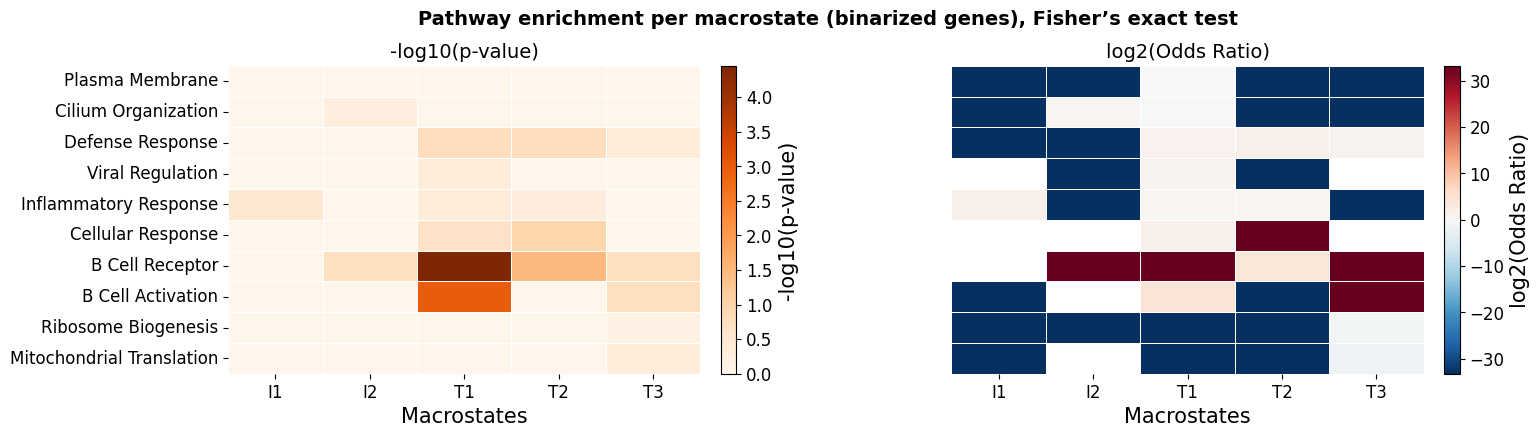

In [17]:
binary_matrix =binary_matrix.T
stats = {}
stats_or = {}

for pathway_name, gene_list in pathways.items():
    stats[pathway_name] = {}
    stats_or[pathway_name] = {}
    for state in binary_matrix.columns:
        state_vector = binary_matrix[state]
        genes = [g for g in gene_list if g in state_vector.index]
        if len(genes) == 0:
            continue
        
        # counts
        in_pathway = state_vector.loc[genes]
        out_pathway = state_vector.drop(index=genes)
        a = (in_pathway == 1).sum()
        b = (in_pathway == 0).sum()
        c = (out_pathway == 1).sum()
        d = (out_pathway == 0).sum()
        table = [[a, b], [c, d]]
        
        oddsratio, pval = fisher_exact(table)
        stats[pathway_name][state] = -np.log10(pval + 1e-10)
        # log2(OR)
        log2_or = np.log2(oddsratio + 1e-10)
        stats_or[pathway_name][state] = log2_or

stats_or_df = pd.DataFrame(stats_or)
stats_df = pd.DataFrame(stats)
order = ["I1", "I2", "T1", "T2", "T3"]
stats_df = stats_df.loc[order]
stats_or_df = stats_or_df.loc[order]

#Plots 
TICK_FONTSIZE = 12
LABEL_FONTSIZE = 15
TITLE_FONTSIZE = 14

fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"wspace": 0.4, "width_ratios": [1, 1]})
fig.suptitle("Pathway enrichment per macrostate (binarized genes), Fisher’s exact test", fontsize=14, fontweight="bold", y=1.02)

# Left heatmap — -log10(p-value)
abs_max_pval = np.nanmax(np.abs(stats_df.T.values))
sns.heatmap(stats_df.T,cmap="Oranges",vmin=0, vmax=abs_max_pval,linewidths=0.5,ax=axes[0],cbar=False,yticklabels=True)
axes[0].set_title("-log10(p-value)", fontsize=TITLE_FONTSIZE)
axes[0].set_xlabel("Macrostates", fontsize=LABEL_FONTSIZE)
axes[0].tick_params(axis='x', labelsize=TICK_FONTSIZE, rotation=0)
axes[0].tick_params(axis='y', labelsize=TICK_FONTSIZE, rotation=0)

sm1 = plt.cm.ScalarMappable(cmap="Oranges", norm=plt.Normalize(vmin=0, vmax=abs_max_pval))
sm1.set_array([])
cbar1 = fig.colorbar(sm1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label("-log10(p-value)", fontsize=LABEL_FONTSIZE)
cbar1.ax.tick_params(labelsize=TICK_FONTSIZE)

# Right heatmap — log2(Odds Ratio)
finite_or = stats_or_df.T.replace([np.inf, -np.inf], np.nan)
abs_max_or = np.nanmax(np.abs(finite_or.values))
or_clipped = stats_or_df.T.replace(np.inf, abs_max_or).replace(-np.inf, -abs_max_or)

sns.heatmap(or_clipped,cmap="RdBu_r", center=0,vmin=-abs_max_or, vmax=abs_max_or,linewidths=0.5,ax=axes[1],cbar=False,yticklabels=False)
axes[1].set_title("log2(Odds Ratio)", fontsize=TITLE_FONTSIZE)
axes[1].set_xlabel("Macrostates", fontsize=LABEL_FONTSIZE)
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', labelsize=TICK_FONTSIZE, rotation=0)

sm2 = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-abs_max_or, vmax=abs_max_or))
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label("log2(Odds Ratio)", fontsize=LABEL_FONTSIZE)
cbar2.ax.tick_params(labelsize=TICK_FONTSIZE)

plt.tight_layout()
#plt.savefig(f"{output_directory}/pathway_enrichment_binarized.png", dpi=300, bbox_inches="tight")
plt.show()

In [194]:
binary_matrix = pd.DataFrame.from_dict(binarized_states, orient="index").fillna(np.nan)
# Active genes per macrostates 
print("=== Active genes per macrostate ===")
for macrostate in binary_matrix.index:
    row = binary_matrix.loc[macrostate].dropna()
    percent=(100*int((row==1).sum()))/len(row)
    print(f"{macrostate}: {int((row==1).sum())} active / {len(row)} total / {percent:.2f} % active")

=== Active genes per macrostate ===
I1: 428 active / 2000 total / 21.40 % active
I2: 523 active / 2000 total / 26.15 % active
T2: 262 active / 2000 total / 13.10 % active
T3: 468 active / 2000 total / 23.40 % active
T1: 204 active / 2000 total / 10.20 % active
